# Drone Detection — Project README ✅

**Short description**
This project detects drones (and similar aerial objects) using an object detection model trained on the dataset in `data/orginal ds/updated dataset/`. The notebook contains data preparation, training, and evaluation steps.

---

## Quick start
- Requirements: Python 3.8+, PyTorch, OpenCV
- Dataset: `data/orginal ds/updated dataset/data.yaml`
- Train (example):
```
# Example (adjust to your training script)
python train.py --data data/orginal\ ds/updated\ dataset/data.yaml --img 640 --epochs 50 --weights yolov5s.pt
```

---

## Results snapshot
**Detection output:**

![Detection results](../../output/my_output%20%281%29/Dorne_detection_res/run_1/results.png)

**Validation predictions:**

![Val predictions](../../output/my_output%20%281%29/Dorne_detection_res/run_1/val_batch1_pred.jpg)

**Confusion matrix:**

![Confusion matrix](../../output/my_output%20%281%29/Dorne_detection_res/run_1/confusion_matrix.png)

---

## Example input images
![Drone example 1](../../drones/drone.png)

![Drone example 2](../../drones/drone2.png)

---

## Notes & next steps
- Check `output/my_output (1)/Dorne_detection_res/run_1/weights/` for `.pt` weights.
- Update this README with additional command examples or results as you iterate.

**Author:** Project workspace


In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [7]:
import torch
print("CUDA available:", torch.cuda.is_available())
print("Device count:", torch.cuda.device_count())
print("Device name:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "No GPU")


CUDA available: False
Device count: 0
Device name: No GPU


In [ ]:

import numpy as np 
import pandas as pd 
import os

import matplotlib.pyplot as plt
import matplotlib.image as mpimg

from PIL import Image

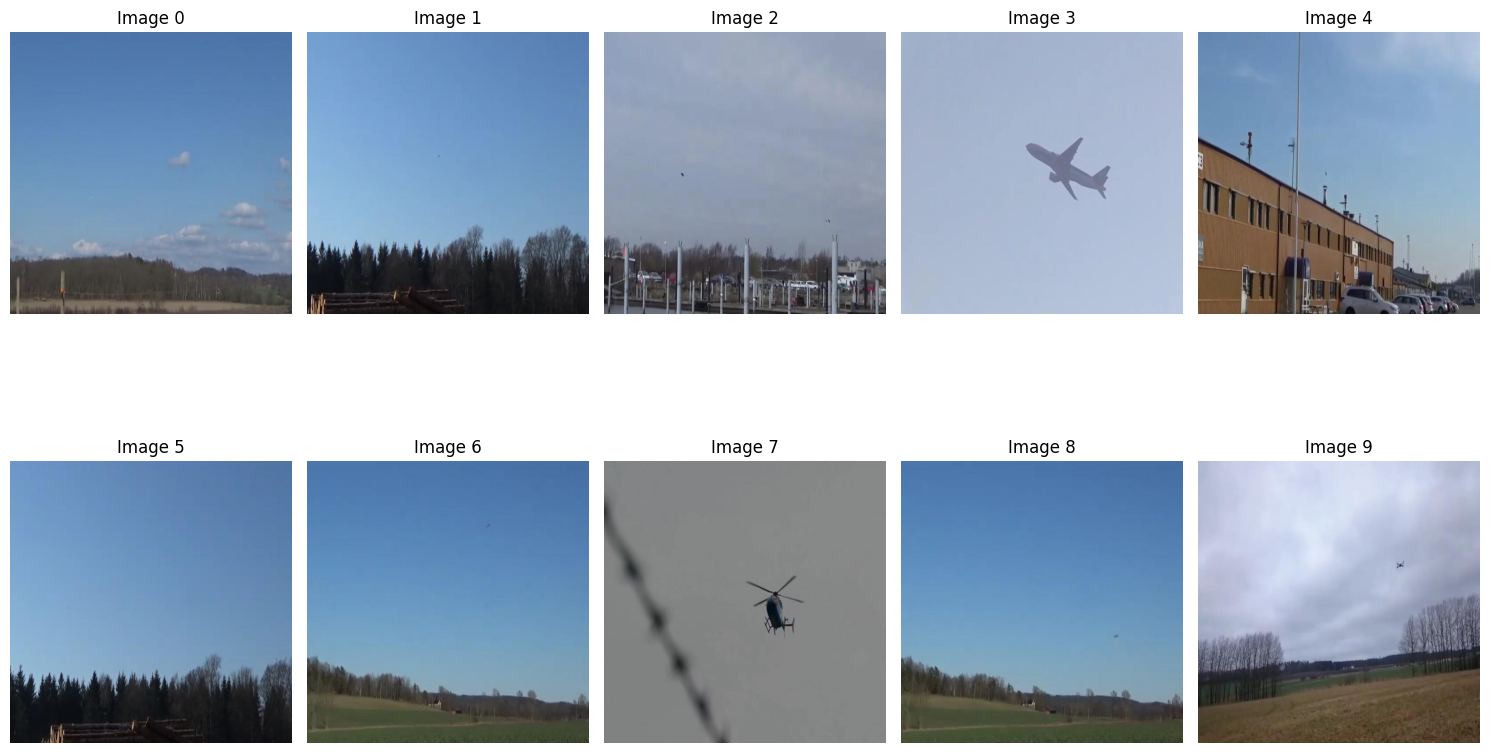

In [2]:

base_dir = '/kaggle/input/drone-detection/drone-detection-new.v5-new-train.yolov8'

image_files = [os.path.join(base_dir, 'train', 'images',x) for x in os.listdir(os.path.join(base_dir, 'train', 'images'))[:10]]
rows, cols = 2, 5
fig, axs = plt.subplots(rows, cols, figsize=(15, 10))

for i, ax in enumerate(axs.flat):
    if i<len(image_files):
        img = mpimg.imread(image_files[i])
        ax.imshow(img)
        ax.set_title(f"Image {i}")
        ax.axis('off')
    else:
        ax.axis('off')

plt.tight_layout()
plt.show()    

In [4]:
! pip install ultralytics
from ultralytics import YOLO

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 25.6 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 3.9 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 88.7 MB/s eta 0:00:00:00:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 63.0 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 32.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 1.9 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 8.0 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 30.3 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 11.5 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 7.6 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 50.9 MB/s eta 0:00:0000:0100:01
  Attempting uninstall: 

In [6]:
model = YOLO('yolo11n.pt') 

In [7]:
yaml_dir = os.path.join(base_dir, 'data.yaml')

results=model.train(
    data=yaml_dir,
    epochs=10,
    batch=32,
    imgsz=512,
    patience=5,              # Early stopping
    val=True,
    name="run_1",
    project="/kaggle/working/Dorne_detection_res",
    device='cuda',
    verbose=True,
    exist_ok=True,
    save=True
)

Ultralytics 8.3.200 🚀 Python-3.11.13 torch-2.6.0+cu124 CUDA:0 (Tesla P100-PCIE-16GB, 16269MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/input/drone-detection/drone-detection-new.v5-new-train.yolov8/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=10, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=512, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=run_1, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_m

/usr/local/lib/python3.11/dist-packages/matplotlib/colors.py:721: RuntimeWarning: invalid value encountered in less
  xa[xa < 0] = -1
/usr/local/lib/python3.11/dist-packages/matplotlib/colors.py:721: RuntimeWarning: invalid value encountered in less
  xa[xa < 0] = -1


                   all        603        497       0.91      0.917      0.943      0.574
              AirPlane        133        133      0.887      0.917      0.959      0.641
                 Drone        220        224      0.864       0.88      0.891      0.426
            Helicopter        140        140      0.978      0.953      0.981      0.655
Speed: 0.1ms preprocess, 1.4ms inference, 0.0ms loss, 2.0ms postprocess per image
Results saved to /kaggle/working/Dorne_detection_res/run_1


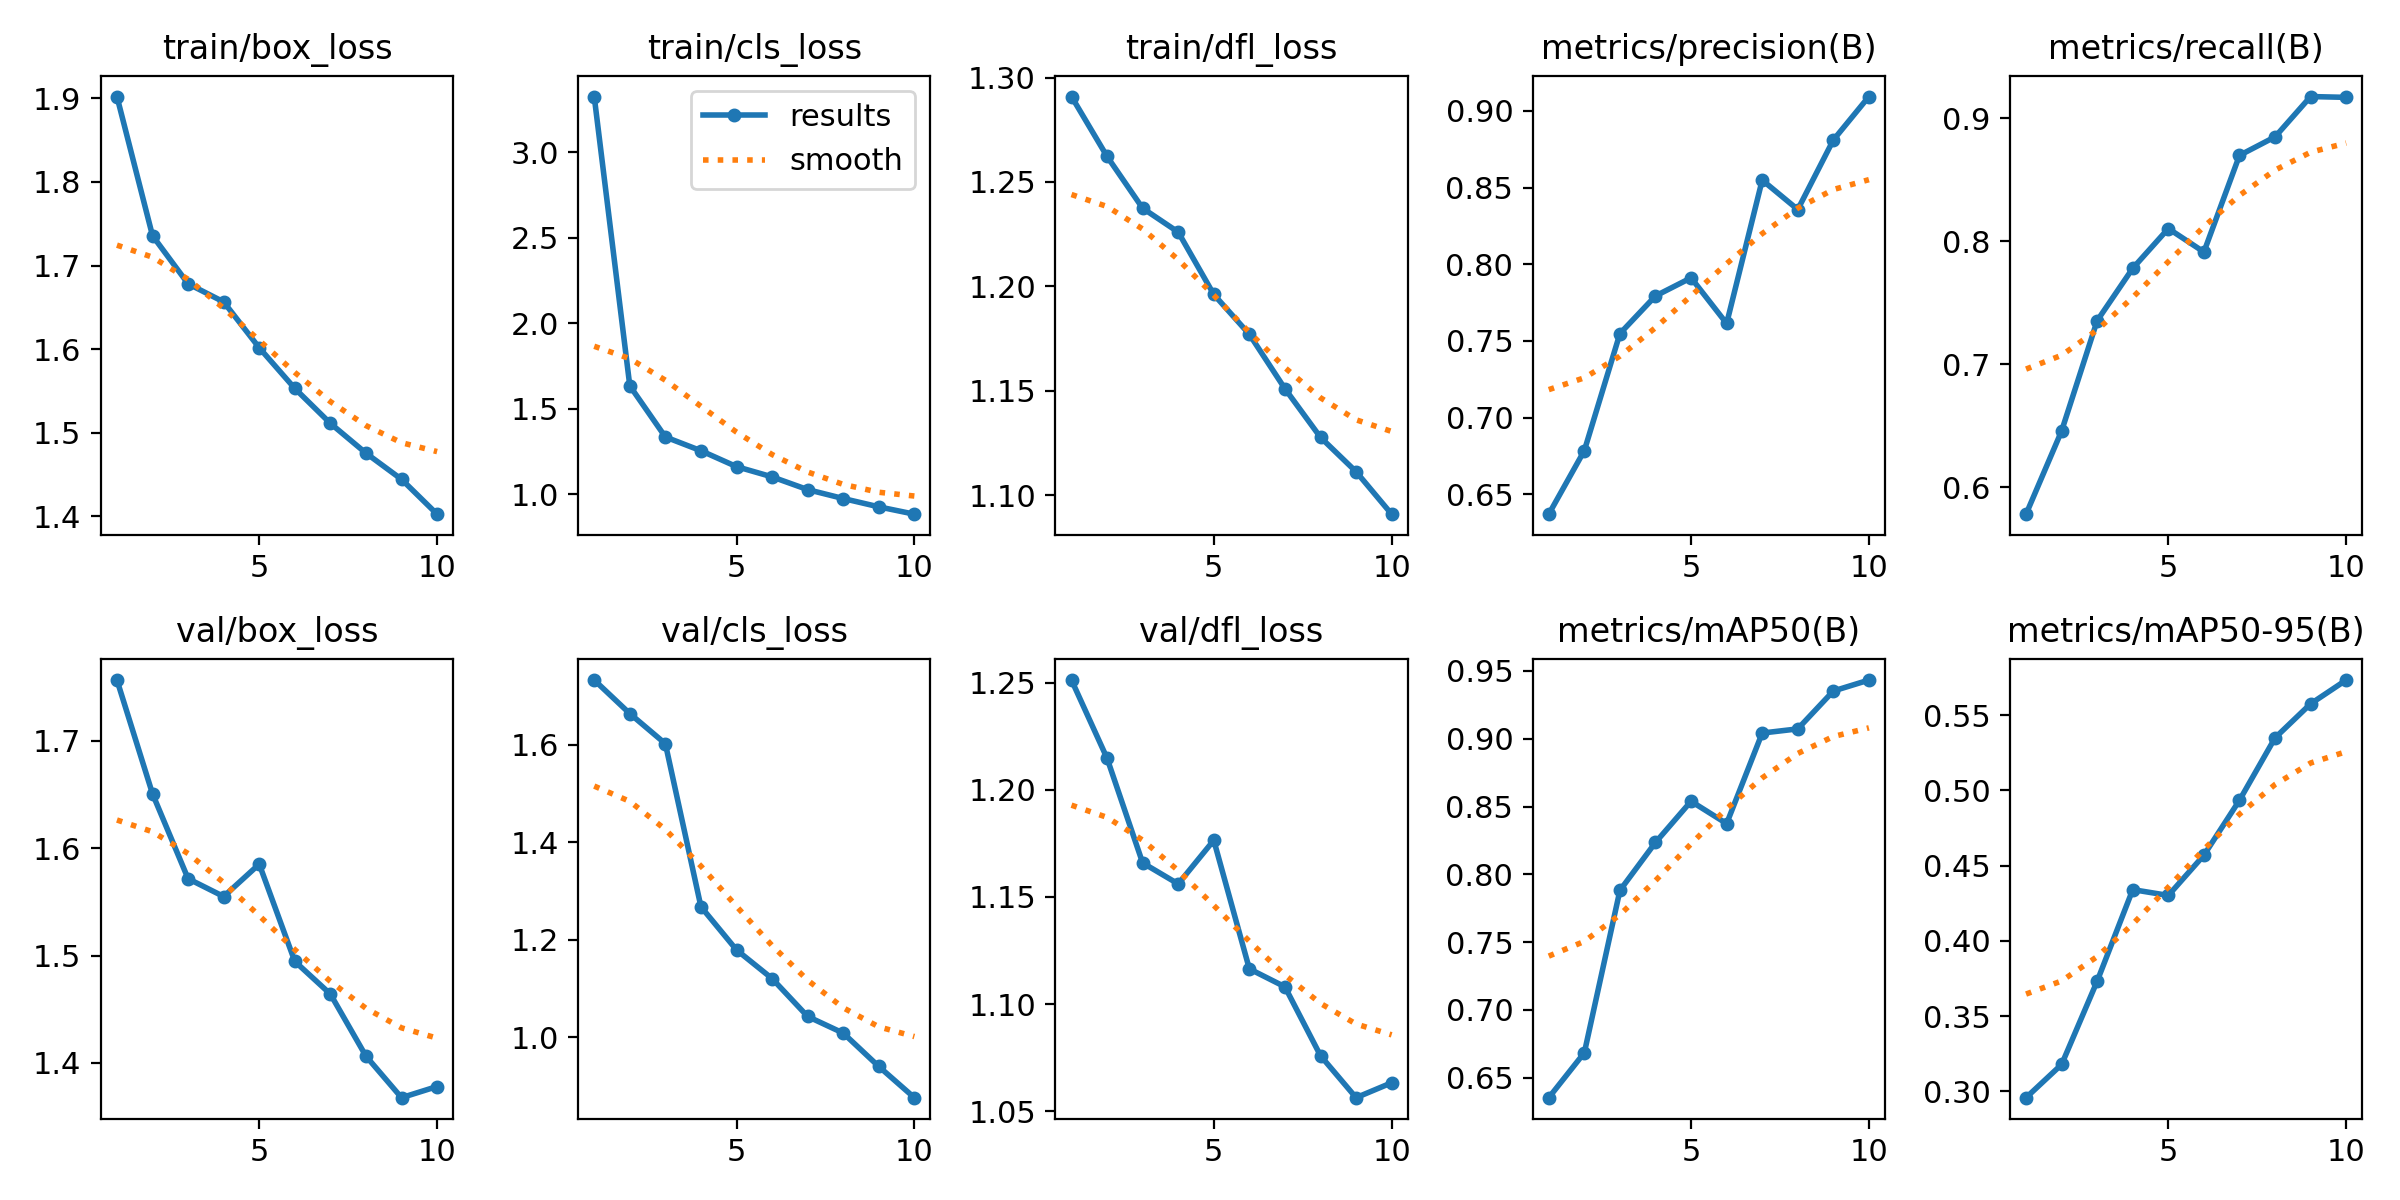

In [12]:
from IPython.display import Image as IPyImage
IPyImage('/kaggle/input/pretrained-model/run_1/results.png', width=600)

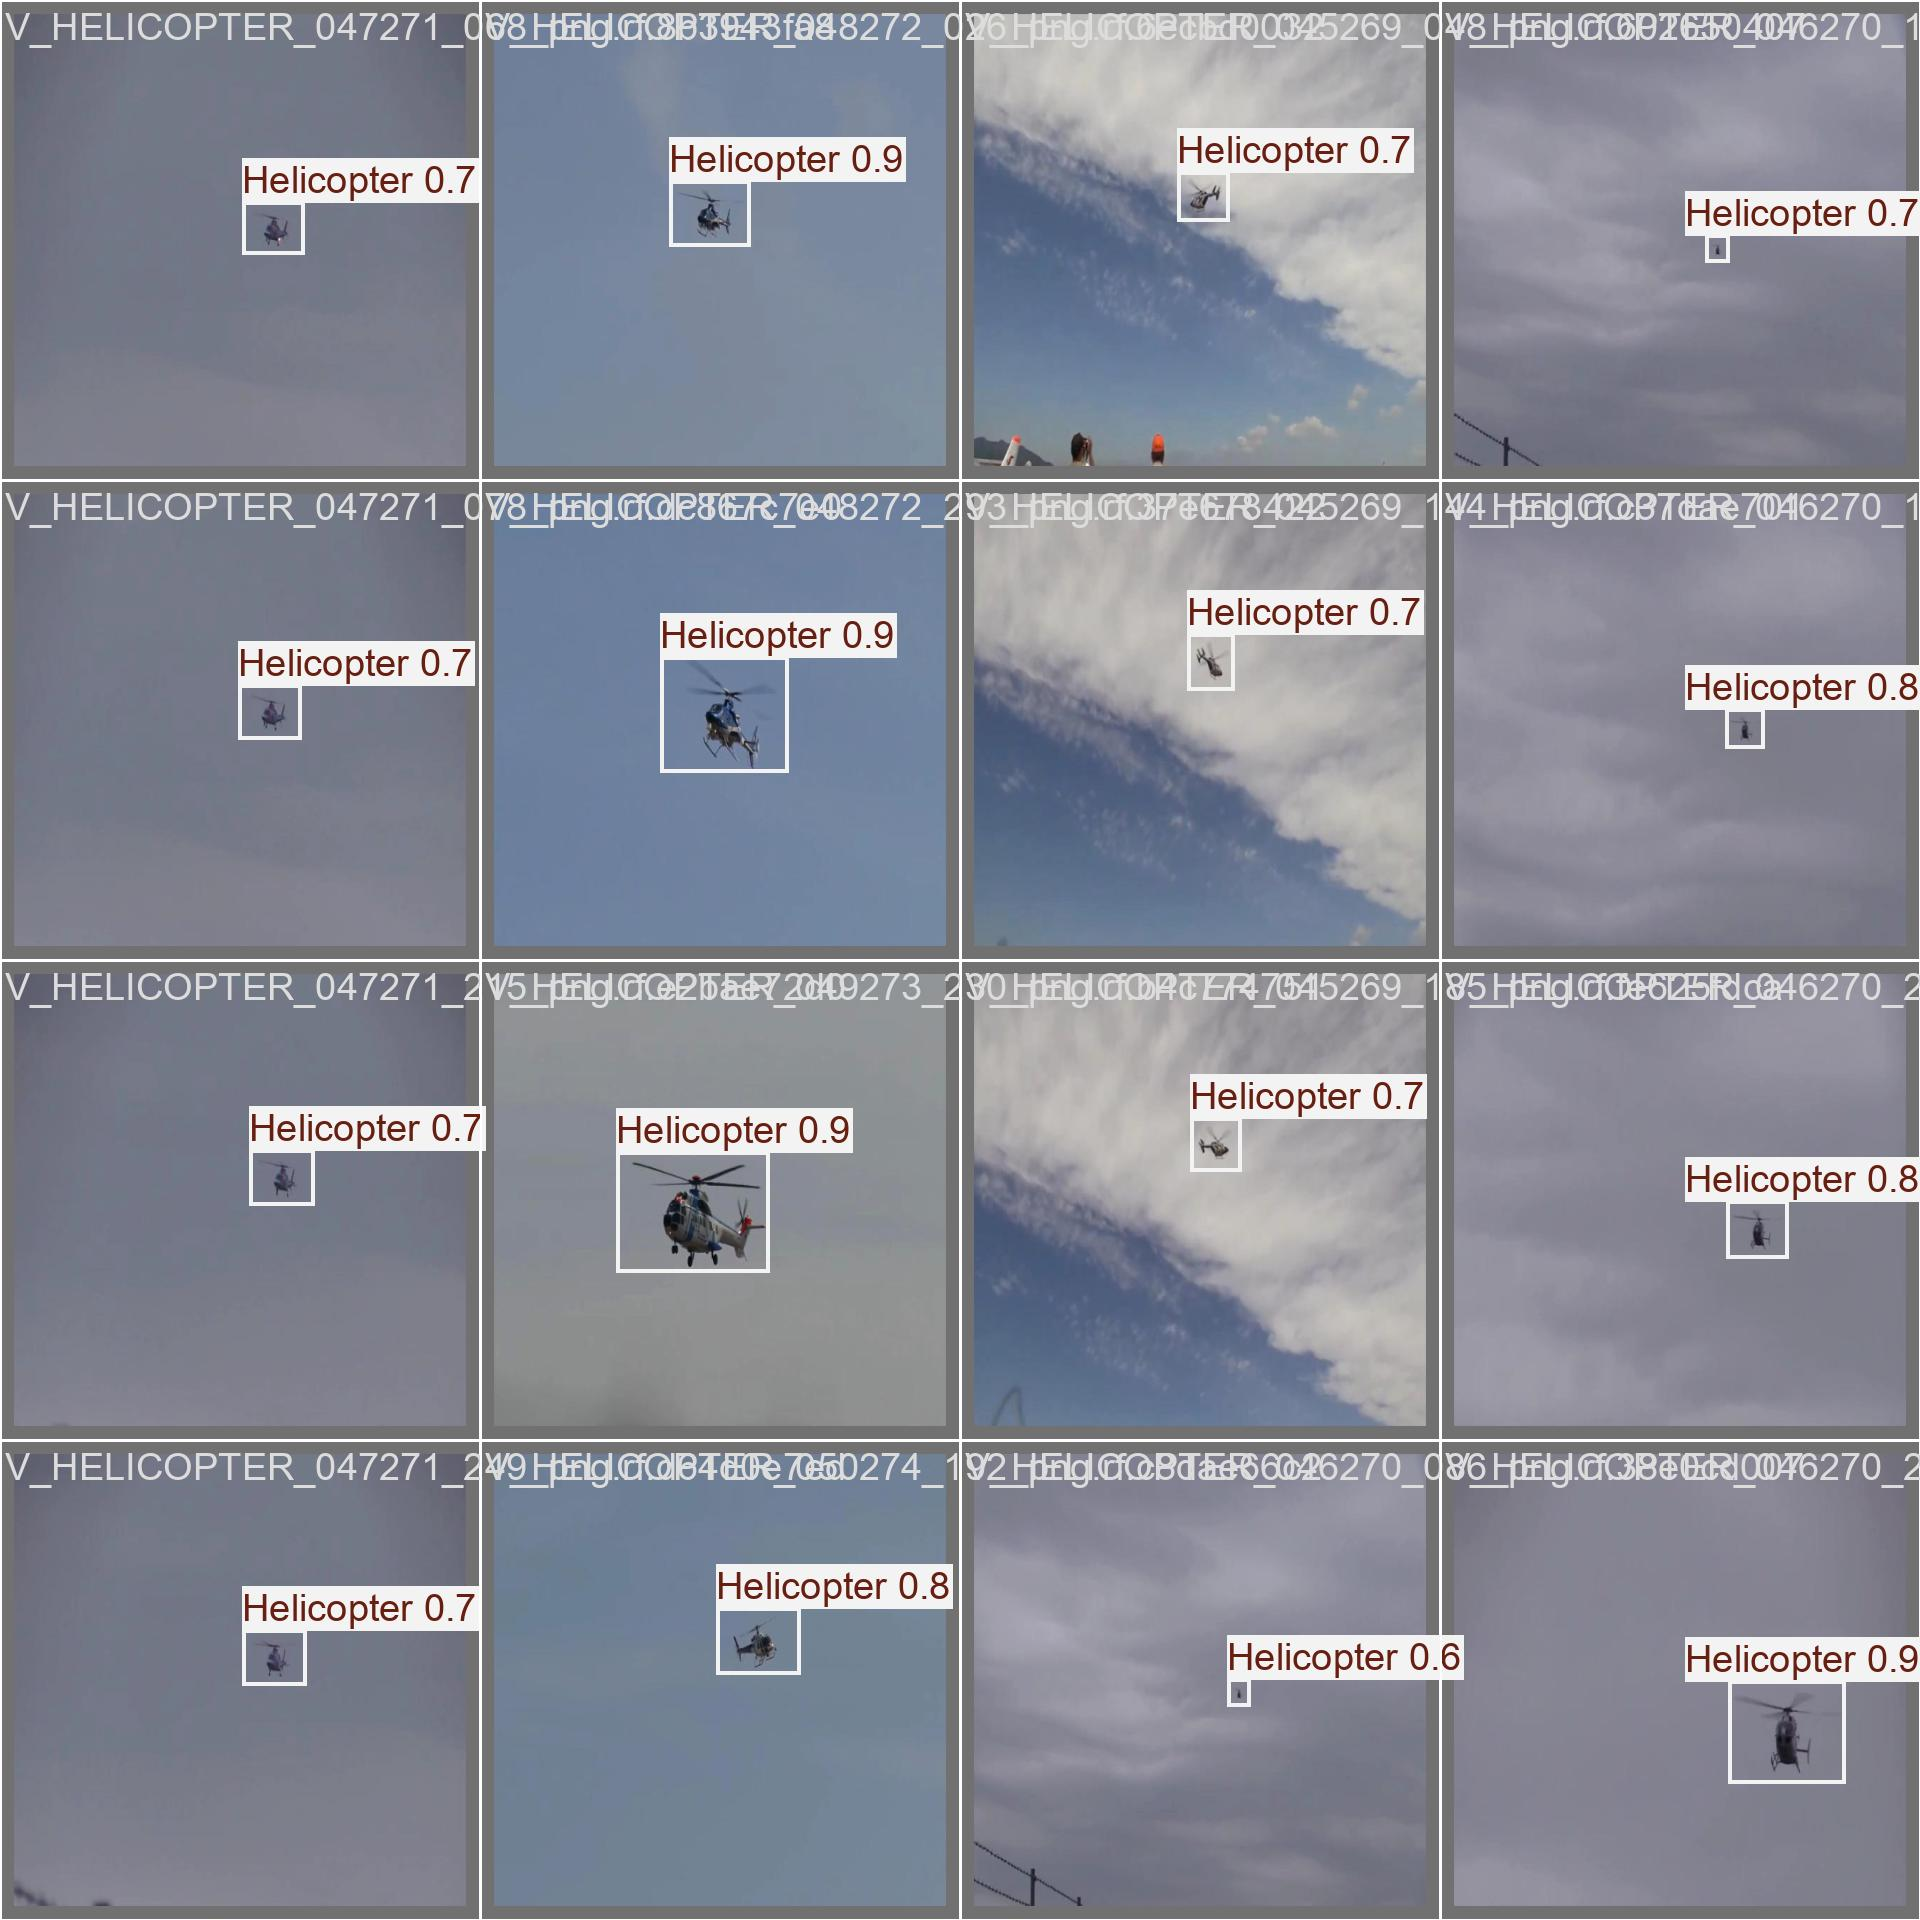

In [24]:
# IPyImage('/kaggle/working/Dorne_detection_res/run_1/val_batch1_labels.jpg', width=600)
IPyImage('/kaggle/input/pretrained-model/run_1/val_batch0_pred.jpg', width=600)

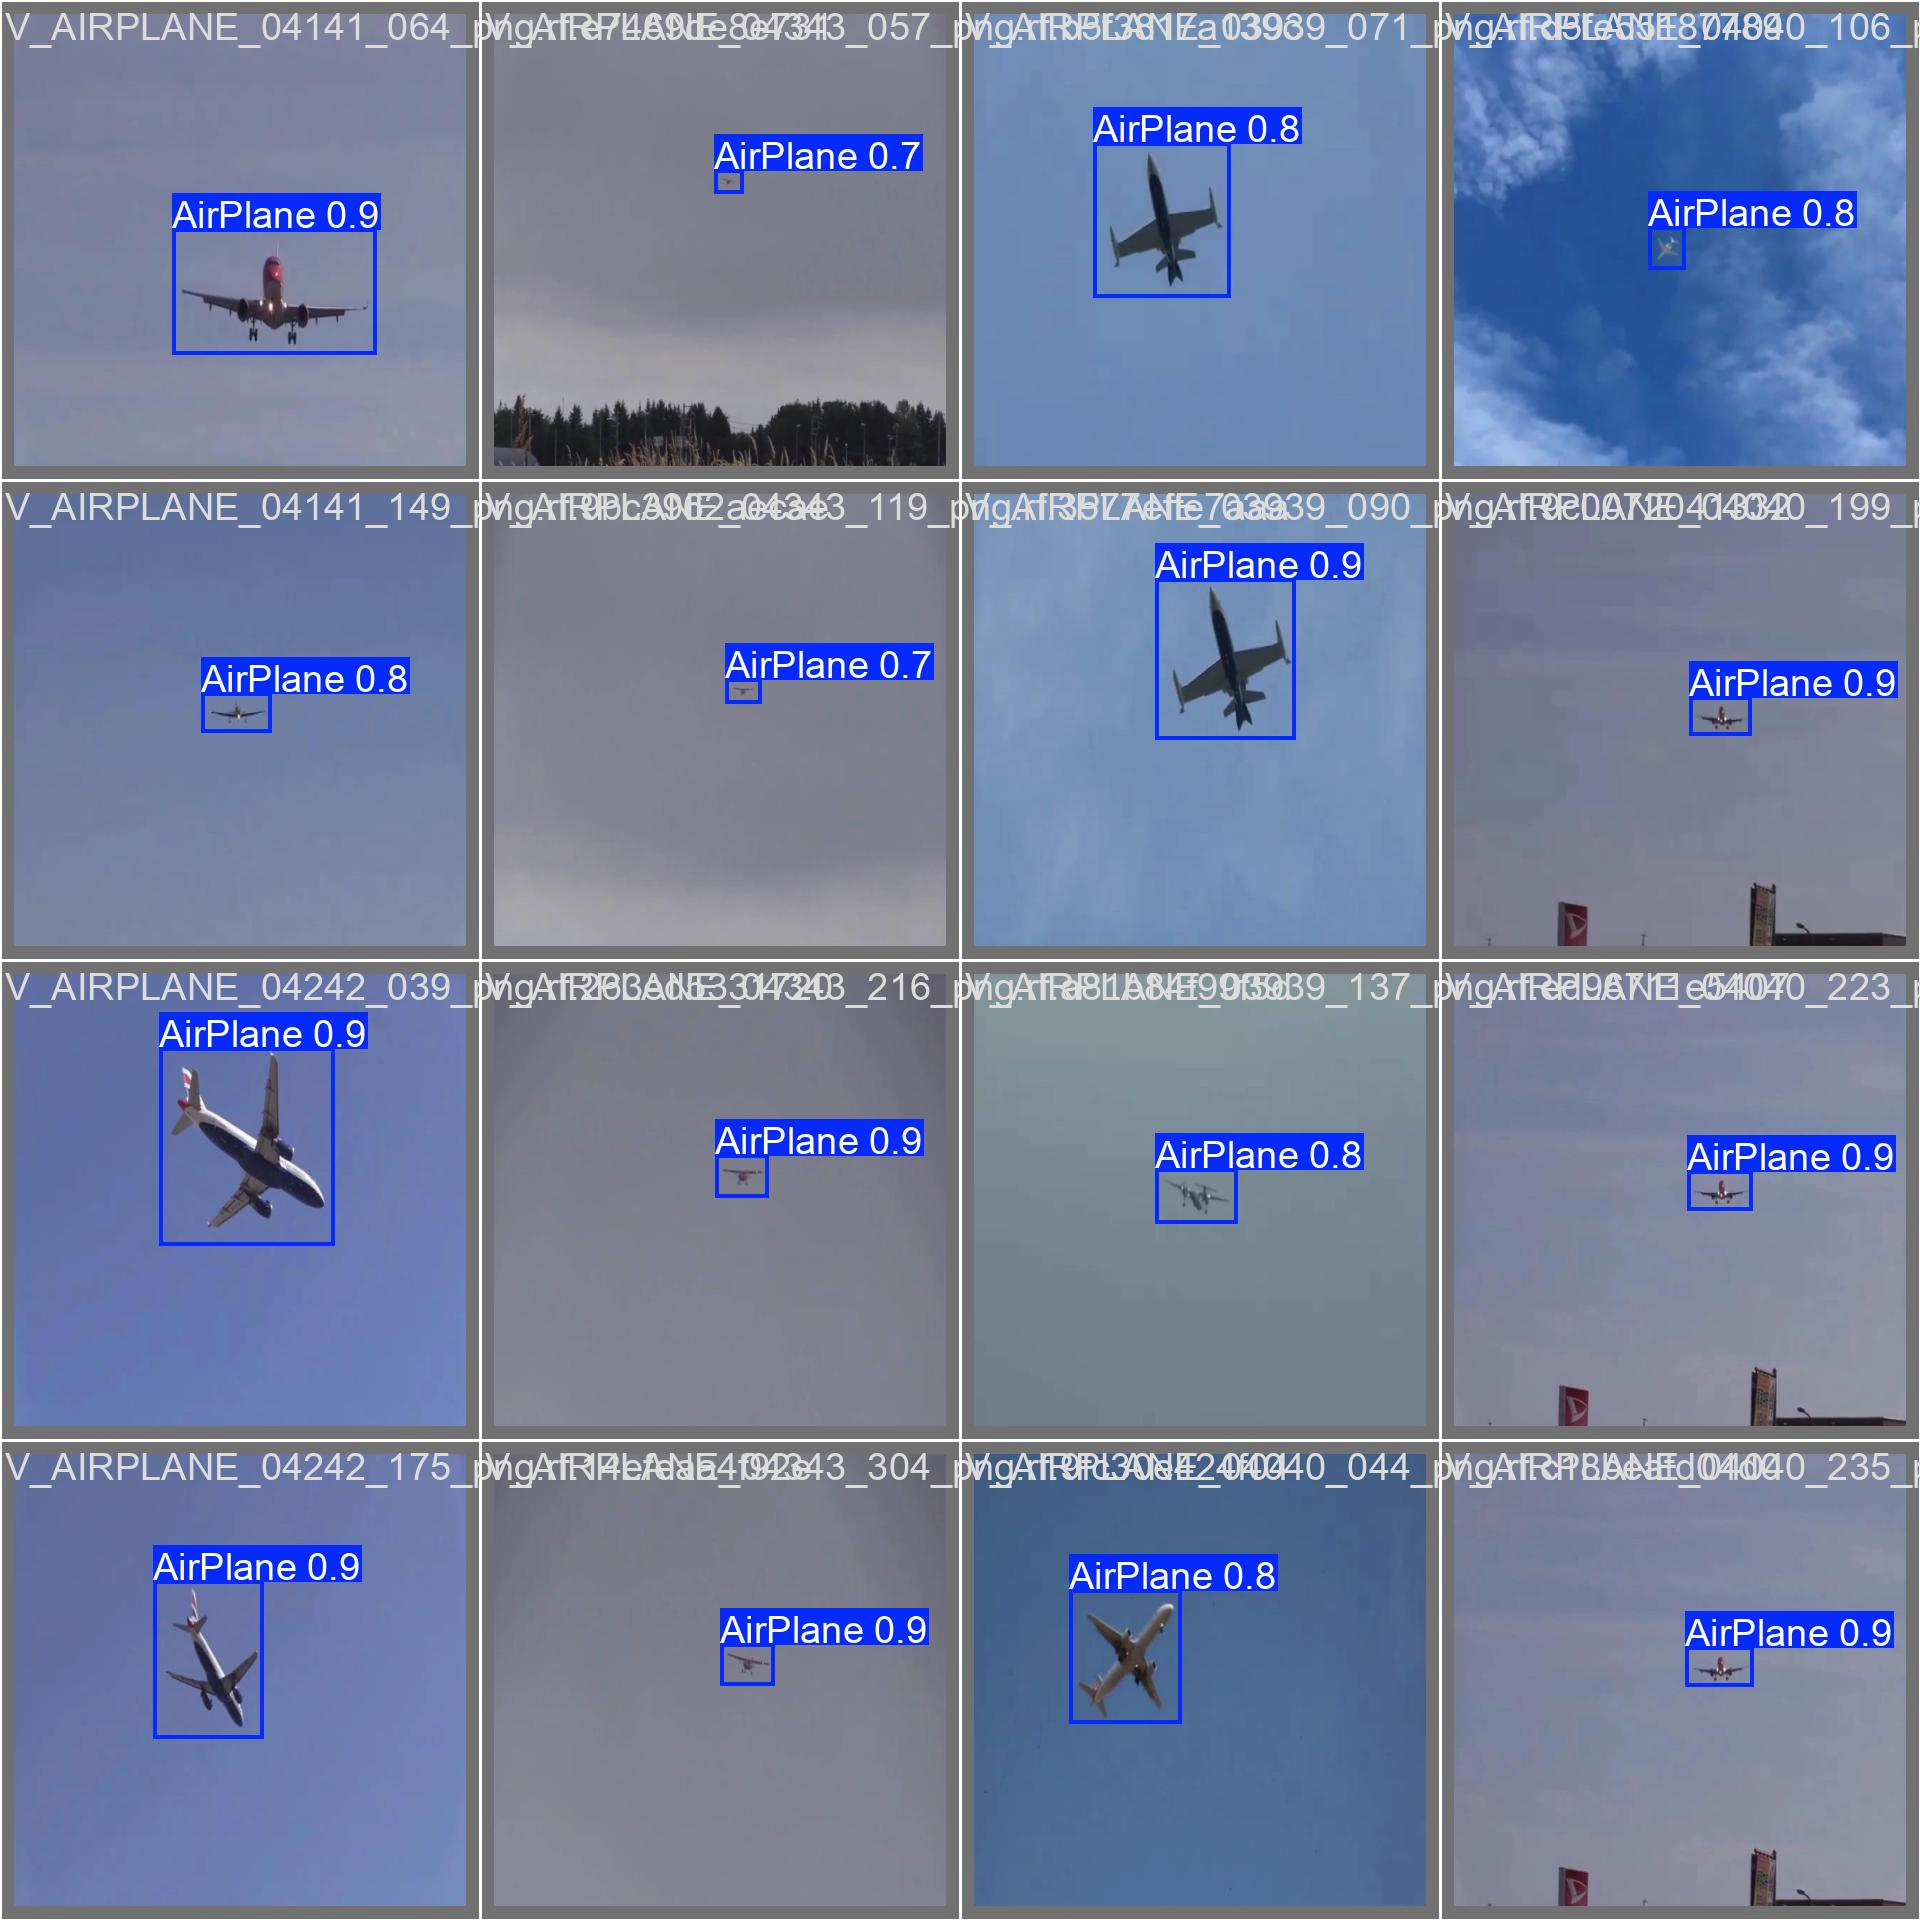

In [21]:
IPyImage('/kaggle/input/pretrained-model/run_1/val_batch1_pred.jpg', width=600)

In [ ]:
best_model_path = '/kaggle/input/pretrained-model/run_1/weights/best.pt' # Path to the best weights from training
best_model = YOLO(best_model_path)
best_model.conf = 0.5
best_model.iou = 0.45

## problem with Drone Class

In [ ]:
results = best_model.predict(
    source='/kaggle/input/drone4334/drone2.png',
    conf=0.48,
    iou=0.9,
    save=True
)



image 1/1 /kaggle/input/drone4334/drone2.png: 256x512 (no detections), 9.6ms
Speed: 1.5ms preprocess, 9.6ms inference, 0.6ms postprocess per image at shape (1, 3, 256, 512)
Results saved to /kaggle/working/Dorne_detection_res/run_1


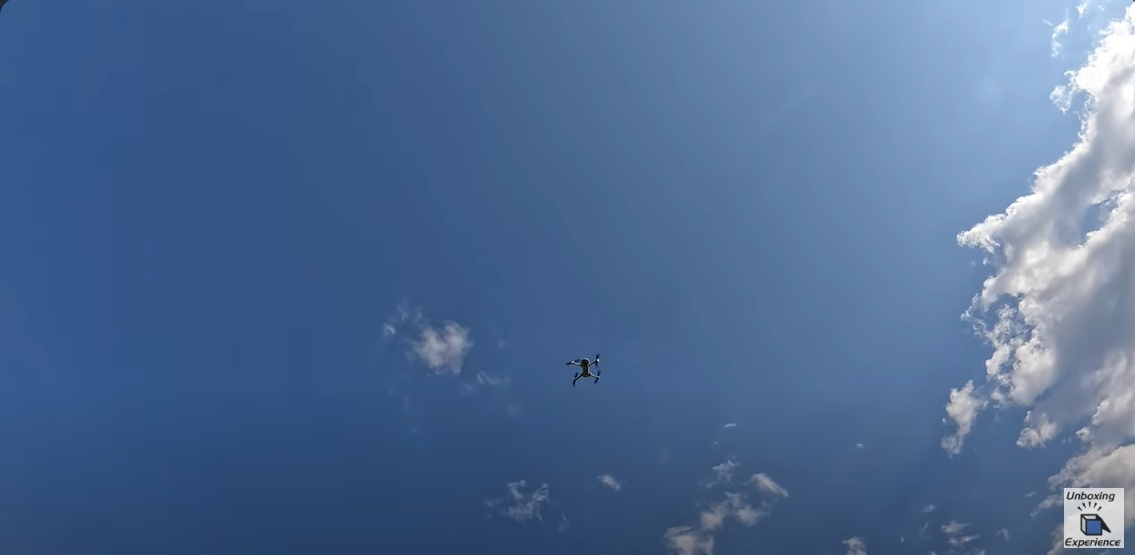

In [76]:
IPyImage('/kaggle/working/Dorne_detection_res/run_1/drone2.jpg', width=600)

In [ ]:
img_test='/kaggle/input/test-data2/Screenshot 2025-09-16 201407.png'
results=best_model.predict(
    source=img_test,  # Folder of test images
    conf=0.3,
    iou=0.45,
    save=True
)



image 1/1 /kaggle/input/test-data2/Screenshot 2025-09-16 201407.png: 416x512 1 AirPlane, 116.8ms
Speed: 2.9ms preprocess, 116.8ms inference, 3.0ms postprocess per image at shape (1, 3, 416, 512)
Results saved to /kaggle/working/runs/detect/predict


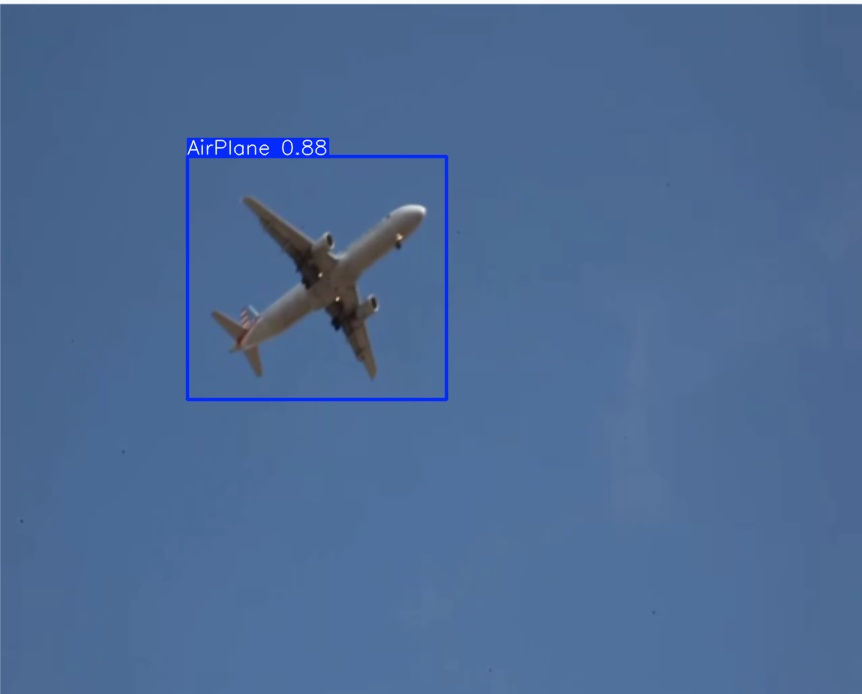

In [33]:
display(Image(filename='/kaggle/working/runs/detect/predict/Screenshot 2025-09-16 201407.jpg'))

In [ ]:
metrics = best_model.val(data='/kaggle/input/drone-detection/drone-detection-new.v5-new-train.yolov8/data.yaml')
print(metrics)

In [ ]:
from IPython.display import FileLink
from IPython.display import Image, display
import os
from collections import Counter

# Define class names (adjust if needed)
class_names = {0: 'AirPlane', 1: 'Drone', 2: 'Helicopter'}

# Define paths to label folders
base_path = r'D:\Courses\AI work\Deep learning\Computer vision\NTI (summer Training)CV\NTI\final project\data\content\orginal ds\updated dataset'
splits = ['train', 'valid', 'test']

# Function to count class instances
def count_classes(label_dir):
    counter = Counter()
    for file in os.listdir(label_dir):
        if file.endswith('.txt'):
            with open(os.path.join(label_dir, file), 'r') as f:
                for line in f:
                    class_id = int(line.strip().split()[0])
                    counter[class_names[class_id]] += 1
    return counter

# Run for each split
for split in splits:
    label_path = os.path.join(base_path, split, 'labels')
    counts = count_classes(label_path)
    print(f"\n📊 Class counts in {split.upper()} set:")
    for cls, count in counts.items():
        print(f"  {cls}: {count}")



📊 Class counts in TRAIN set:
  Drone: 6104
  AirPlane: 2274
  Helicopter: 2374

📊 Class counts in VALID set:
  Drone: 468
  AirPlane: 133
  Helicopter: 140

📊 Class counts in TEST set:
  AirPlane: 128
  Drone: 237
  Helicopter: 114


# Adding anther dataset with drone examples

In [ ]:
# !pip install roboflow

# from roboflow import Roboflow
# rf = Roboflow(api_key="6qc0wGQv6n66YhqcIIYw")
# project = rf.workspace("test-oi9qv").project("drones-mev5s")
# version = project.version(1)
# dataset = version.download("yolov11")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.7/88.7 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 24.3 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 38.6 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.2/4.2 MB 60.1 MB/s eta 0:00:00:00:01
  Attempting uninstall: idna
    Found existing installation: idna 3.10
    Uninstalling idna-3.10:
      Successfully uninstalled idna-3.10
  Attempting uninstall: opencv-python-headless
    Found existing installation: opencv-python-headless 4.11.0.86
    Uninstalling opencv-python-headless-4.11.0.86:
      Successfully uninstalled opencv-python-headless-4.11.0.86
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
bigframes 2.8.0 requires google-cloud-bigque


Extracting Dataset Version Zip to drones-1 in yolov11:: 100%|██████████| 13794/13794 [00:03<00:00, 3754.23it/s]


## problem with labels in yaml file 
 ### in original dataset drone with label 1 
 ### in added dataset drone with label 0 
#### Do it Locally 

In [ ]:
# import os

# # Path to your labels folder
# labels_path = r"D:\Courses\AI work\Deep learning\Computer vision\NTI (summer Training)CV\NTI\final project\data\content\drone--1\train\labels"

# # Define how to change the first number
# def remap_class_id(old_id):
#     # Example: change 0 -> 1, keep others the same
#     if old_id == 0:
#         return 1
#     return old_id

# # Loop through all txt files
# for file in os.listdir(labels_path):
#     if file.endswith(".txt"):
#         file_path = os.path.join(labels_path, file)

#         new_lines = []
#         with open(file_path, "r") as f:
#             for line in f:
#                 parts = line.strip().split()
#                 if parts:
#                     old_id = int(parts[0])
#                     parts[0] = str(remap_class_id(old_id))  # change first number
#                     new_lines.append(" ".join(parts))

#         # Overwrite file with updated content
#         with open(file_path, "w") as f:
#             f.write("\n".join(new_lines))


# Exploring some Samples after adding more drone examples

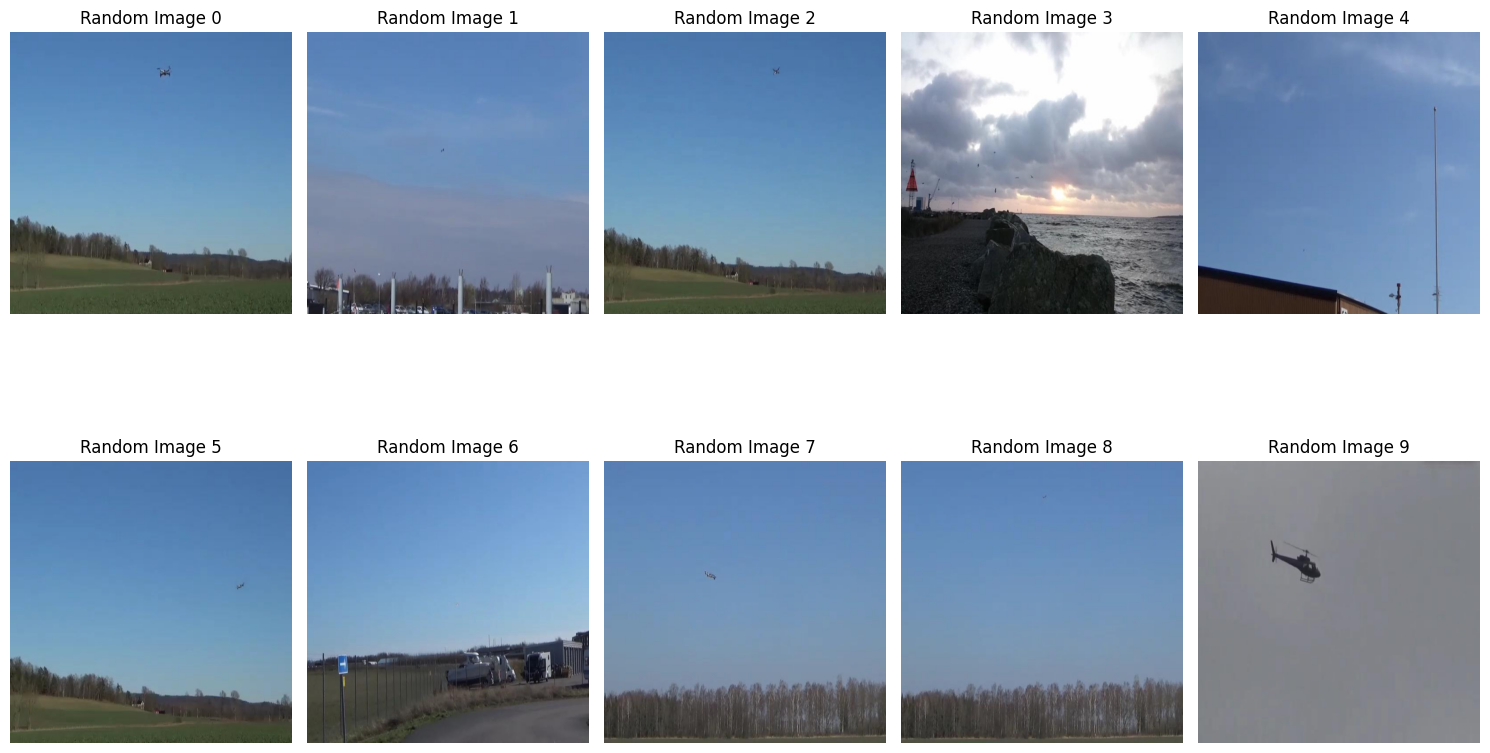

In [9]:
import os
import random
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

base_dir = '/kaggle/input/drone-detection-dataset/updated dataset'
image_dir = os.path.join(base_dir, 'train', 'images')

# Get all image filenames
all_images = os.listdir(image_dir)

# Choose 10 random images
random_images = random.sample(all_images, 10)

# Build full paths
image_files = [os.path.join(image_dir, img) for img in random_images]

# Plot
rows, cols = 2, 5
fig, axs = plt.subplots(rows, cols, figsize=(15, 10))

for i, ax in enumerate(axs.flat):
    if i < len(image_files):
        img = mpimg.imread(image_files[i])
        ax.imshow(img)
        ax.set_title(f"Random Image {i}")
        ax.axis('off')
    else:
        ax.axis('off')

plt.tight_layout()
plt.show()


# Training Model_1 (Yolo 11)

In [ ]:
# model = YOLO('yolo11s.pt') 
# yaml_dir = os.path.join(base_dir, 'data.yaml')

# results=model.train(
#     data=yaml_dir,
#     epochs=10,
#     batch=32,
#     imgsz=640,
#     patience=5,              # Early stopping
#     val=True,
#     name="run_1",
#     project="/kaggle/working/Dorne_detection_res",
#     device='cuda',
#     verbose=True,
#     exist_ok=True,
#     save=True
# )

In [ ]:
# res=model.predict(
#     source='/kaggle/input/test-data2/Screenshot 2025-09-16 201214.png',  
#     conf=0.36,        # Confidence threshold
#     iou=0.45,        # IoU threshold
#     save=True        # Saves annotated image to /kaggle/runs/detect/
# )


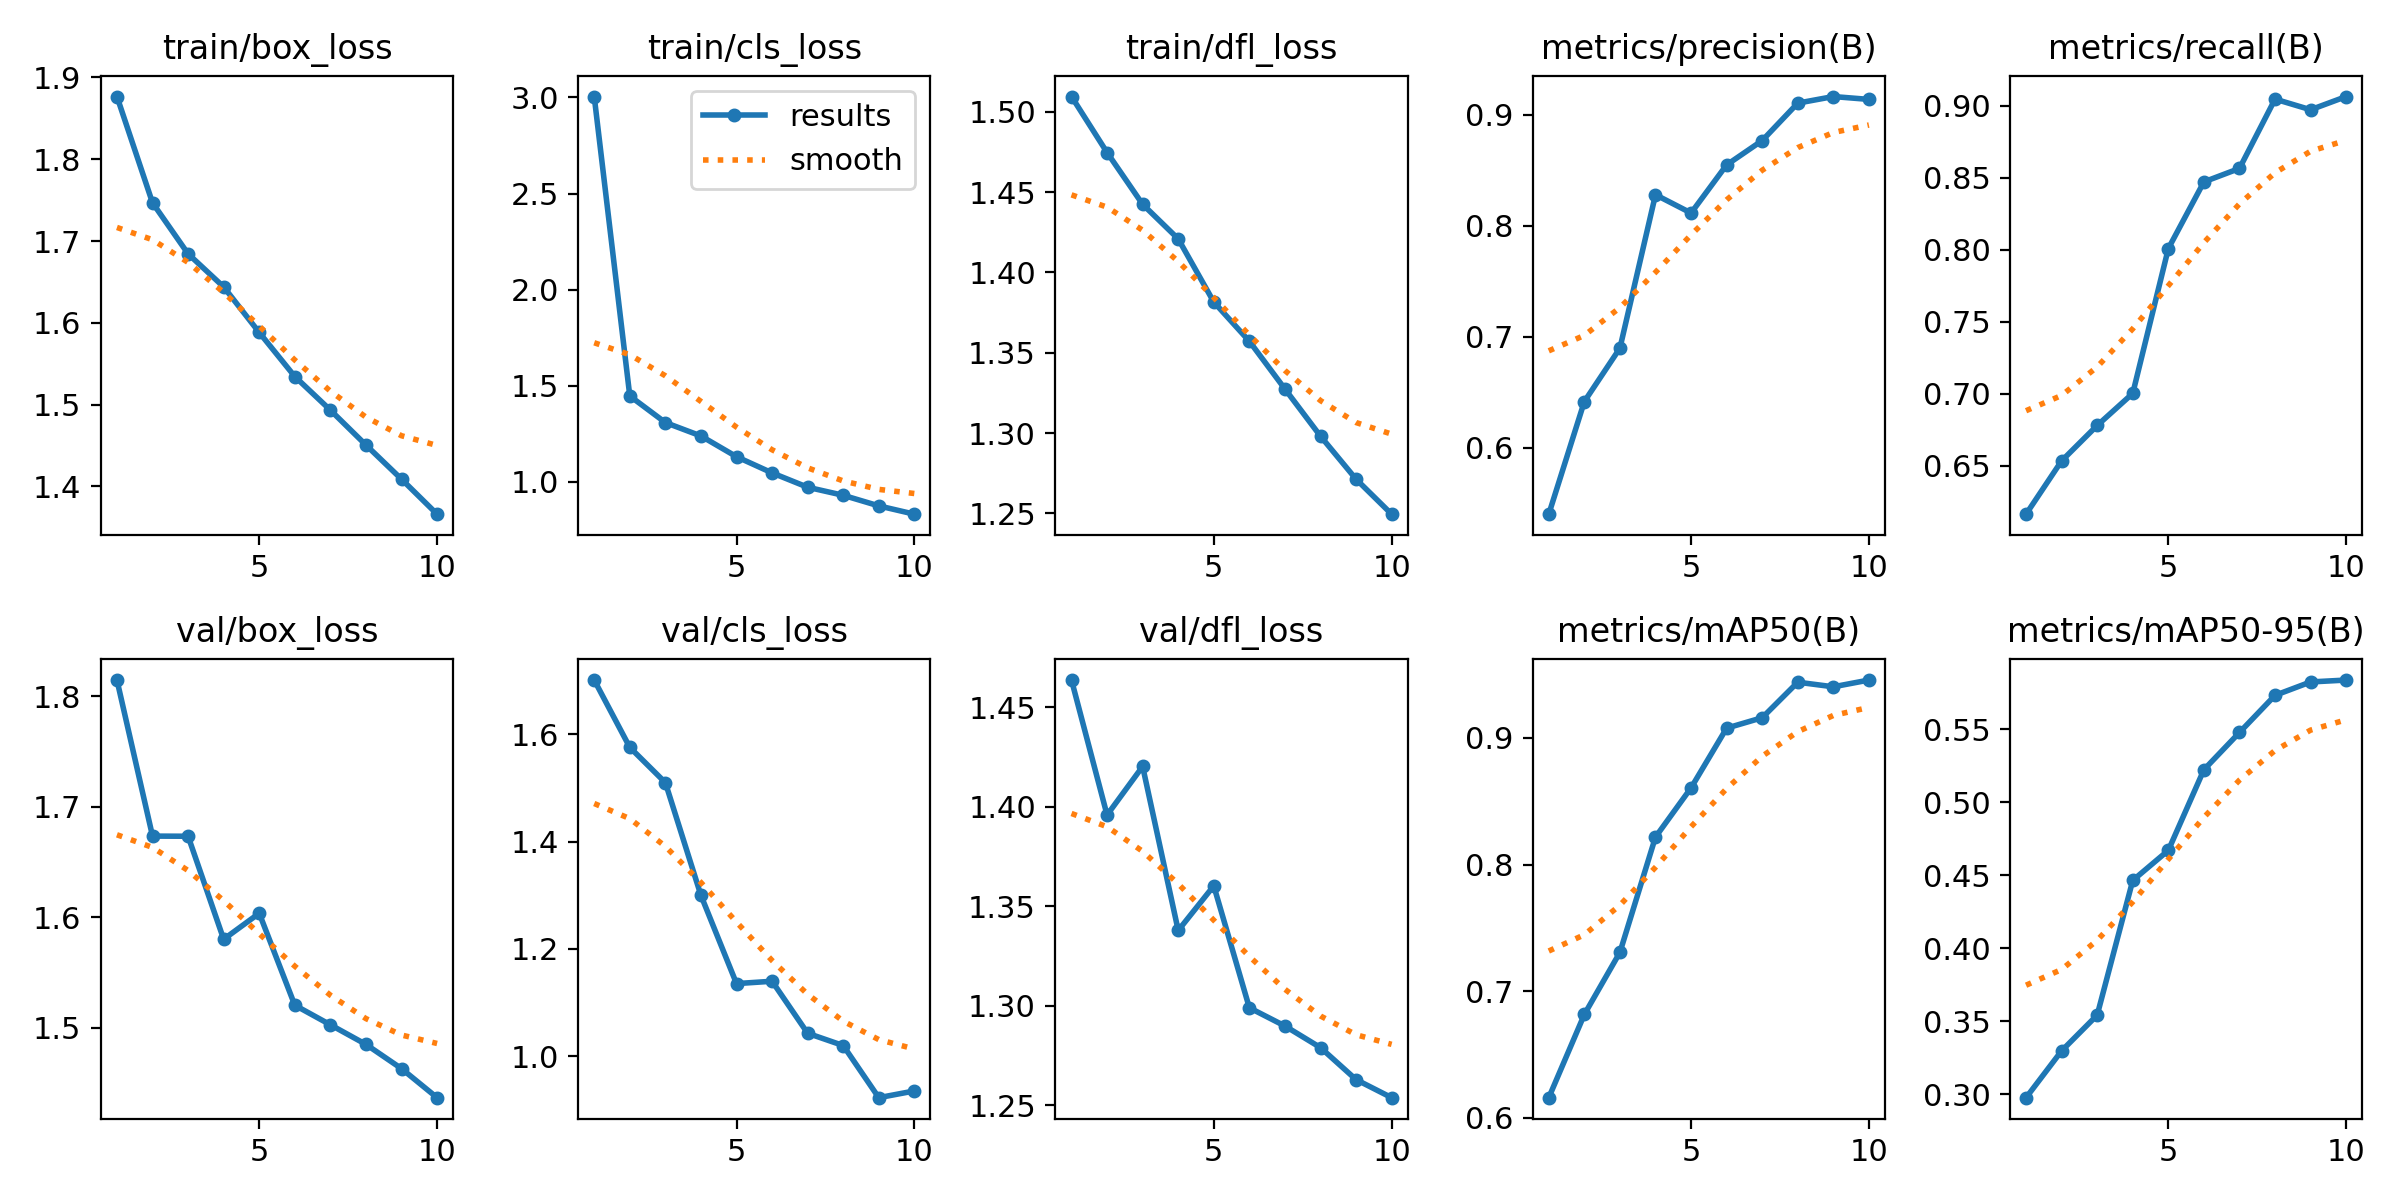

In [10]:
IPyImage('/kaggle/input/pretrained-model-2/results.png', width=600)


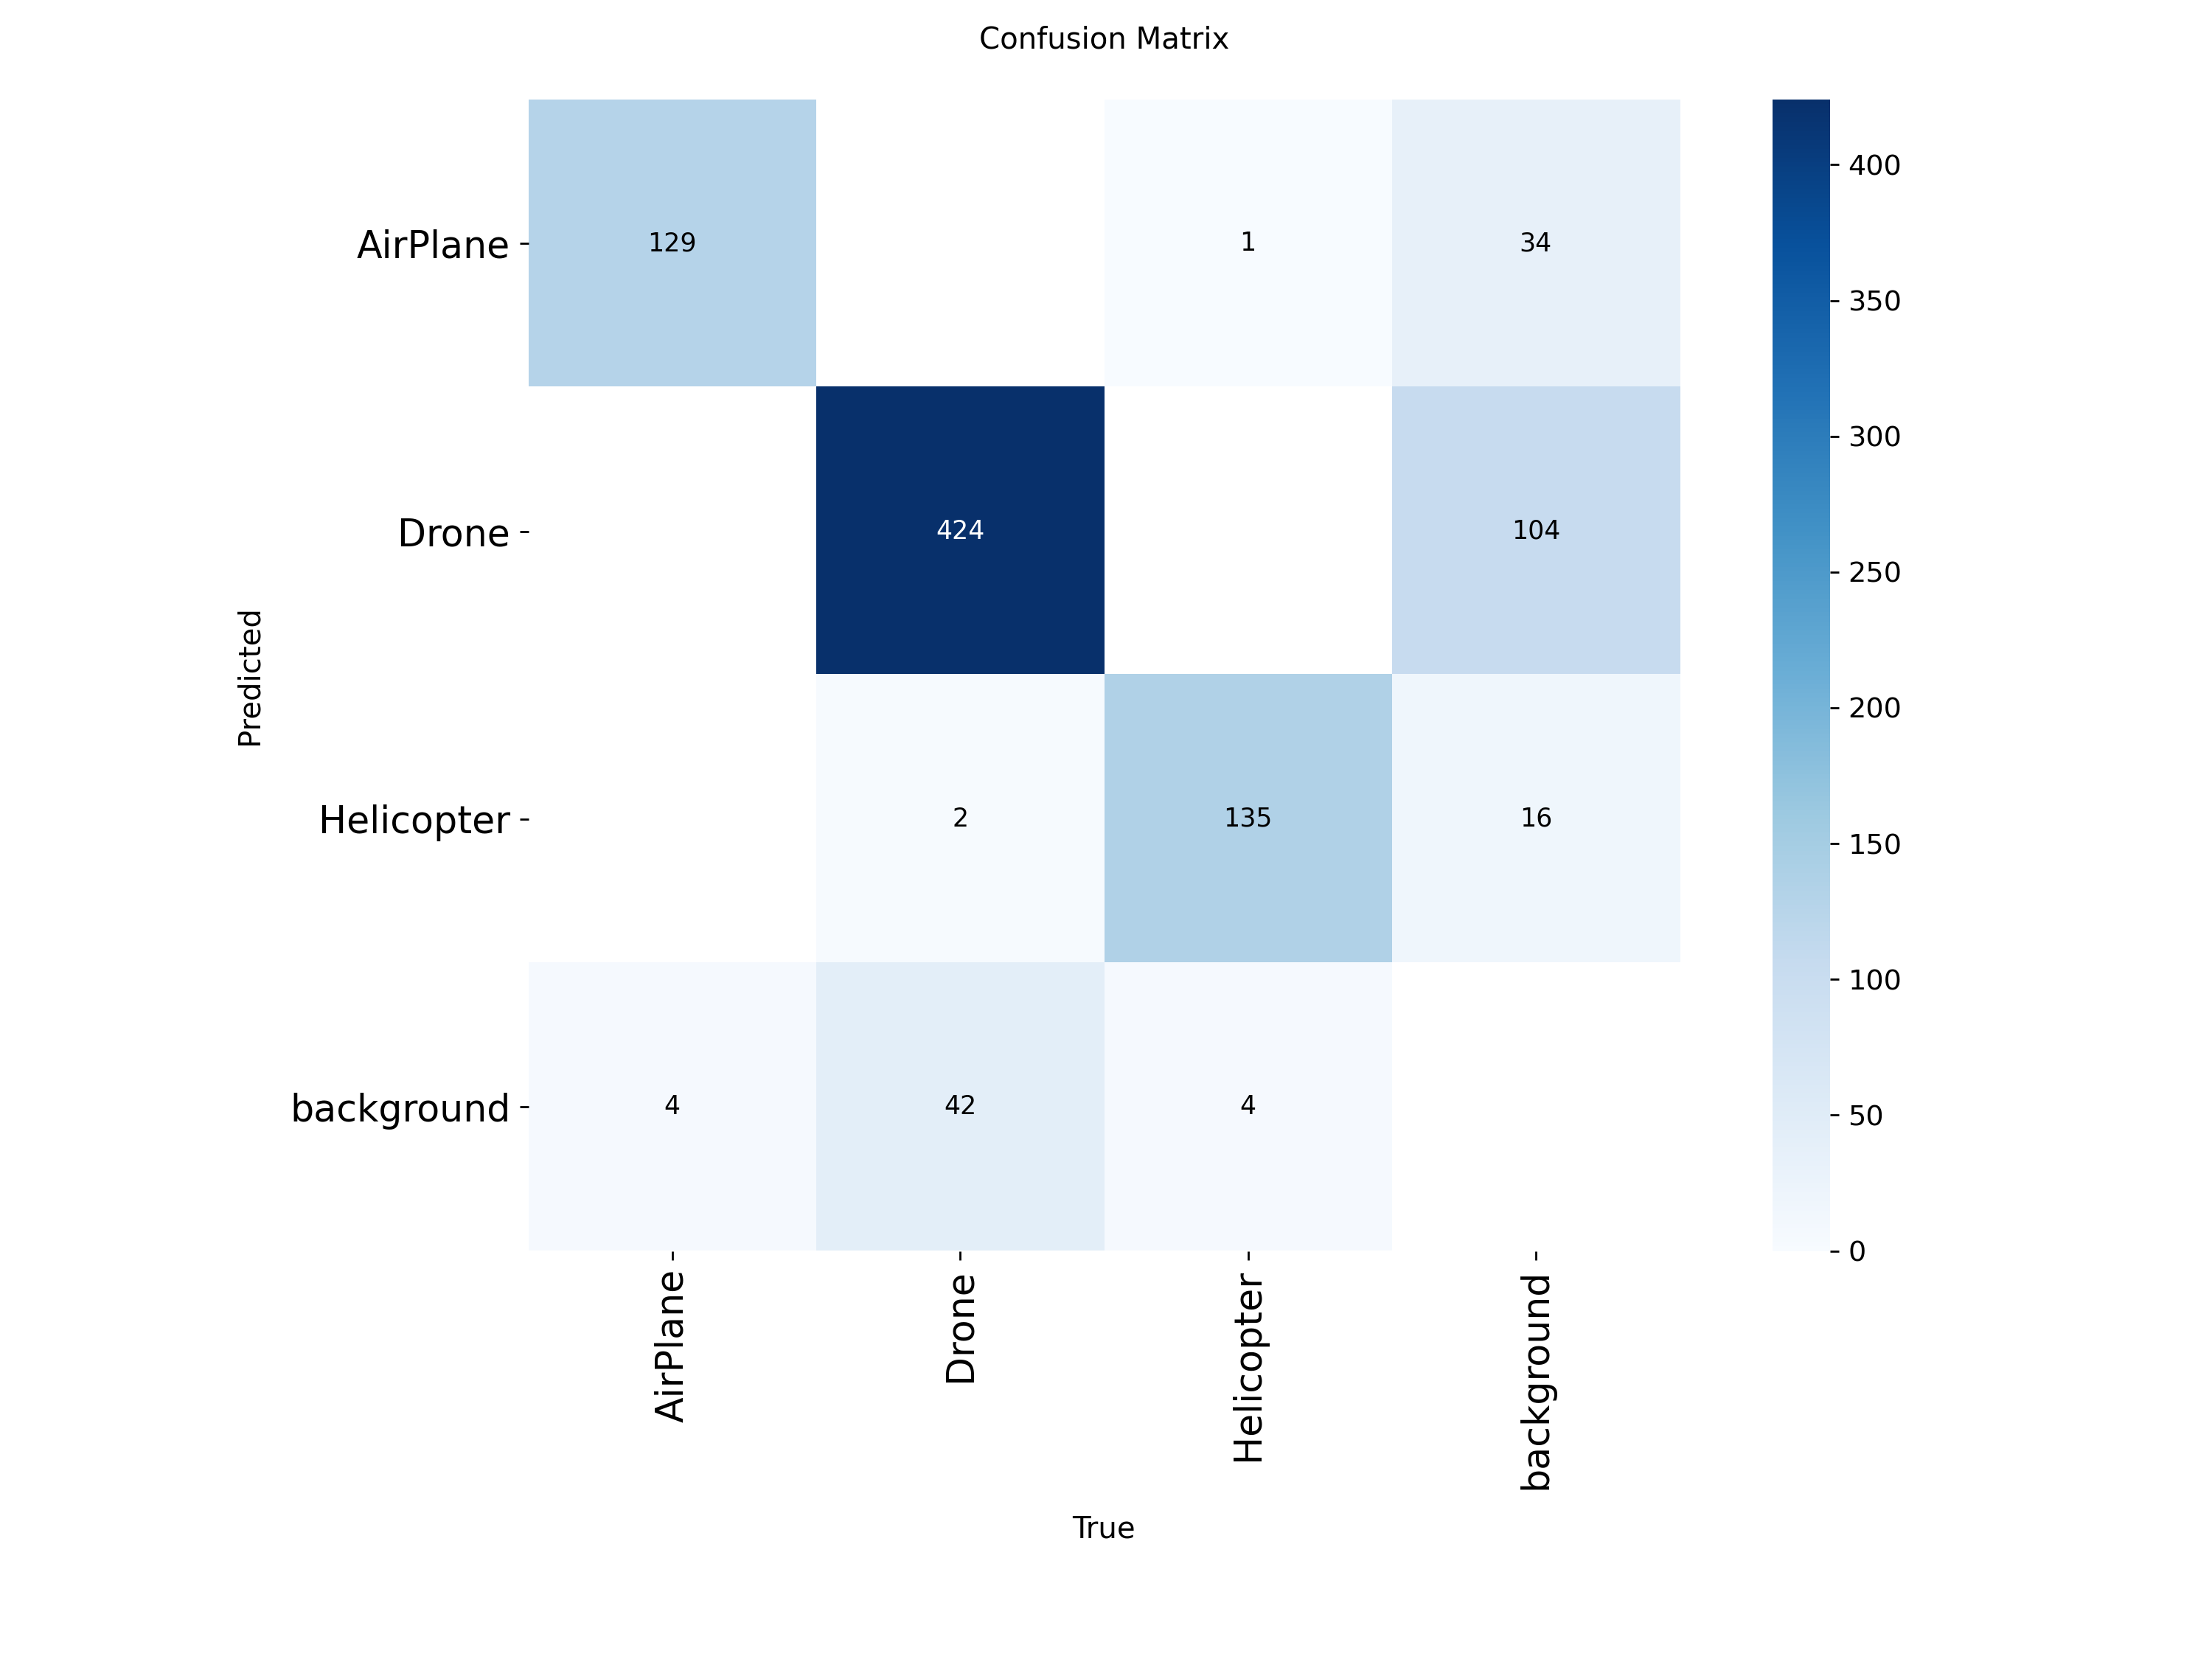

In [20]:
IPyImage('/kaggle/input/pretrained-model-2/confusion_matrix.png', width=600)


In [11]:
best_model_path = '/kaggle/input/pretrained-model-2/best.pt' 
best_model = YOLO(best_model_path)

best_model.conf = 0.5     
best_model.iou = 0.45

In [ ]:
results = best_model.predict('/kaggle/input/drone-detection-dataset/updated dataset/valid/images', save=True, conf=0.5, iou=0.5)


In [14]:
metrics = best_model.val(data='/kaggle/input/drone-detection-dataset/updated dataset/data.yaml')  # Use your dataset config

Ultralytics 8.3.202 🚀 Python-3.11.13 torch-2.6.0+cu124 CUDA:0 (Tesla P100-PCIE-16GB, 16269MiB)
val: Fast image access ✅ (ping: 0.1±0.2 ms, read: 33.4±15.8 MB/s, size: 17.1 KB)
val: Scanning /kaggle/input/drone-detection-dataset/updated dataset/valid/labels... 765 images, 110 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 765/765 312.8it/s 2.4s0.1s
WARNING ⚠️ val: Cache directory /kaggle/input/drone-detection-dataset/updated dataset/valid is not writeable, cache not saved.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 48/48 5.1it/s 9.4s0.1s


/usr/local/lib/python3.11/dist-packages/matplotlib/colors.py:721: RuntimeWarning: invalid value encountered in less
  xa[xa < 0] = -1
/usr/local/lib/python3.11/dist-packages/matplotlib/colors.py:721: RuntimeWarning: invalid value encountered in less
  xa[xa < 0] = -1


                   all        765        741      0.912      0.905      0.944      0.584
              AirPlane        133        133      0.888      0.898      0.965      0.629
                 Drone        382        468      0.896      0.861      0.893      0.438
            Helicopter        140        140      0.953      0.957      0.975      0.686
Speed: 0.5ms preprocess, 5.5ms inference, 0.0ms loss, 1.5ms postprocess per image
Results saved to /kaggle/working/runs/detect/val


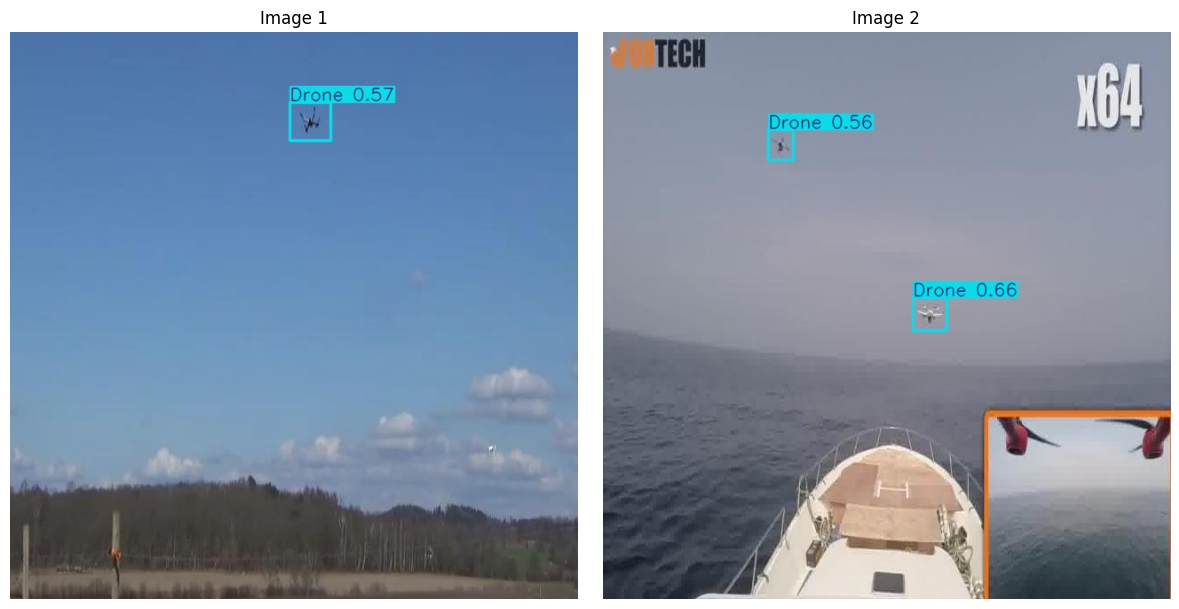

In [16]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

# Load the images
img1 = mpimg.imread('/kaggle/working/runs/detect/predict/V_DRONE_106216_265_png.rf.3f6c83cfed825eaaeda1c1193e673d05.jpg')
img2 = mpimg.imread('/kaggle/working/runs/detect/predict/video18_1985_JPEG_jpg.rf.b40884bdbea85ecfbaf99d99a7ab2b38.jpg')

# Create subplots
fig, axs = plt.subplots(1, 2, figsize=(12, 6))

# Display each image
axs[0].imshow(img1)
axs[0].axis('off')
axs[0].set_title('Image 1')

axs[1].imshow(img2)
axs[1].axis('off')
axs[1].set_title('Image 2')


plt.tight_layout()
plt.show()


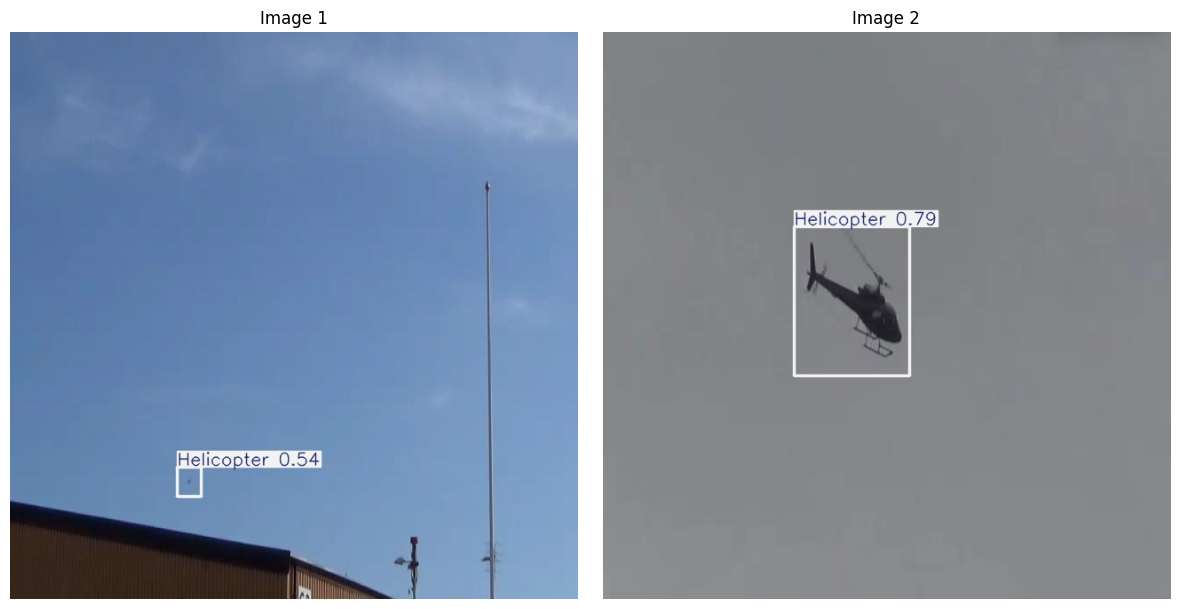

In [21]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

# Load the images
img1 = mpimg.imread('/kaggle/working/runs/detect/predict/V_HELICOPTER_015239_306_png.rf.e50f9bf932a01af45919508e607c0236.jpg')
img2 = mpimg.imread('/kaggle/working/runs/detect/predict/V_HELICOPTER_023247_033_png.rf.b84027ce7cada34fbc5cc360ab81d8da.jpg')

# Create subplots
fig, axs = plt.subplots(1, 2, figsize=(12, 6))

# Display each image
axs[0].imshow(img1)
axs[0].axis('off')
axs[0].set_title('Image 1')

axs[1].imshow(img2)
axs[1].axis('off')
axs[1].set_title('Image 2')

axs[1].imshow(img2)
axs[1].axis('off')
axs[1].set_title('Image 2')

plt.tight_layout()
plt.show()


# Samples out of the distribution of the dataset

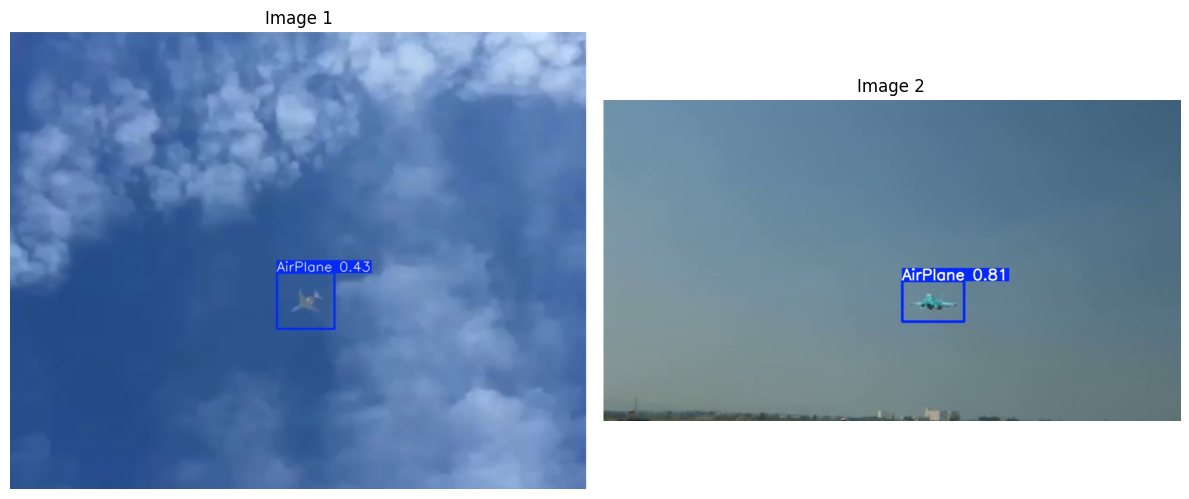

In [22]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

# Load the images
img1 = mpimg.imread('/kaggle/input/pretrained-model-2/Screenshot 2025-09-16 201442.jpg')
img2 = mpimg.imread('/kaggle/input/pretrained-model-2/Screenshot 2025-09-16 201214.jpg')

# Create subplots
fig, axs = plt.subplots(1, 2, figsize=(12, 6))

# Display each image
axs[0].imshow(img1)
axs[0].axis('off')
axs[0].set_title('Image 1')

axs[1].imshow(img2)
axs[1].axis('off')
axs[1].set_title('Image 2')

axs[1].imshow(img2)
axs[1].axis('off')
axs[1].set_title('Image 2')

plt.tight_layout()
plt.show()


In [ ]:
res = model.predict(
    source='/kaggle/input/test-datset/Recording 2025-09-17 172326.mp4',  # Path to your uploaded video
    save=True,                              # Saves output video with detections
    conf=0.5,
    iou=.45
)
Video('/kaggle/working/Dorne_detection_res/run_1/Recording 2025-09-17 172326.avi', width=600)

# model 2 

In [26]:
model2 = YOLO('yolov8n.pt') 

base_dir = '/kaggle/input/drone-detection-dataset/updated dataset'

yaml_dir = os.path.join(base_dir, 'data.yaml')

results2=model2.train(
    data=yaml_dir,
    epochs=10,
    batch=32,
    imgsz=640,
    patience=5,              # Early stopping
    val=True,
    name="run_1",
    project="/kaggle/working/model_2_res",
    device='cuda',
    verbose=True,
    exist_ok=True,
    save=True
)

Ultralytics 8.3.202 🚀 Python-3.11.13 torch-2.6.0+cu124 CUDA:0 (Tesla P100-PCIE-16GB, 16269MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/input/drone-detection-dataset/updated dataset/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=10, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=run_1, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patien

/usr/local/lib/python3.11/dist-packages/matplotlib/colors.py:721: RuntimeWarning: invalid value encountered in less
  xa[xa < 0] = -1
/usr/local/lib/python3.11/dist-packages/matplotlib/colors.py:721: RuntimeWarning: invalid value encountered in less
  xa[xa < 0] = -1


                   all        765        741      0.913      0.903      0.949      0.605
              AirPlane        133        133      0.871      0.887      0.954      0.673
                 Drone        382        468      0.927      0.863      0.909      0.455
            Helicopter        140        140      0.942      0.957      0.984      0.687
Speed: 0.2ms preprocess, 2.0ms inference, 0.0ms loss, 1.6ms postprocess per image
Results saved to /kaggle/working/model_2_res/run_1


In [ ]:
best_model_path = '/kaggle/working/model_2_res/run_1/weights/best.pt' # Path to the best weights from training
best_model_2 = YOLO(best_model_path)

best_model.conf = 0.5     
best_model.iou = 0.45

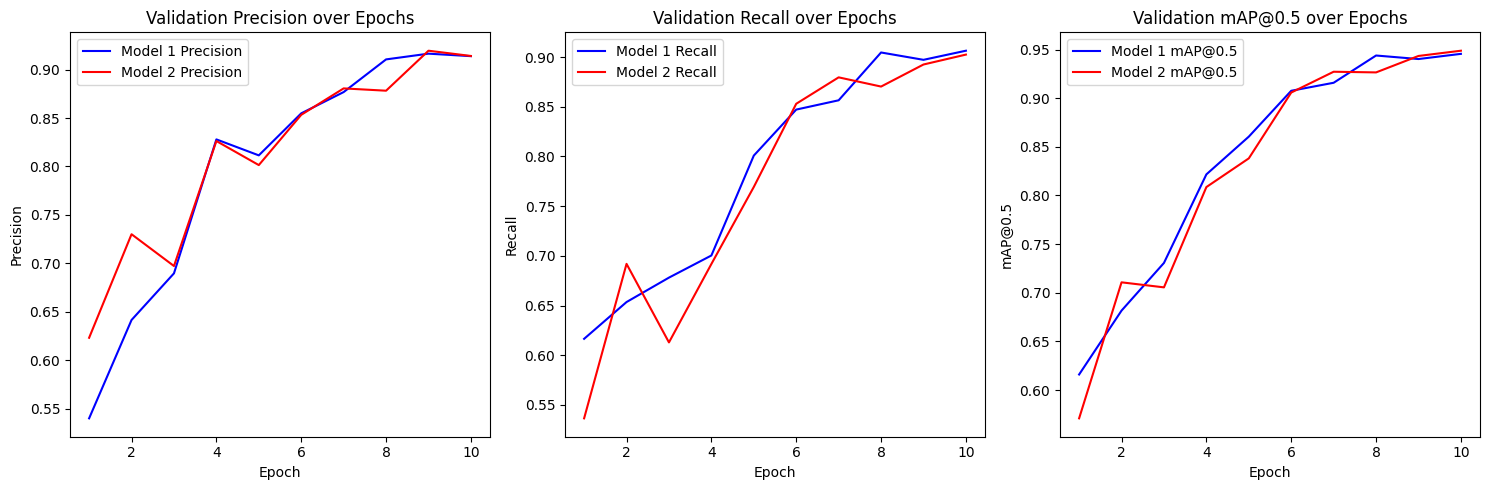

In [27]:
import pandas as pd
import matplotlib.pyplot as plt

# Paths for the two models' results
path1 = "/kaggle/input/pretrained-model-2/results.csv"   # Model 1
path2 = "/kaggle/working/model_2_res/run_1/results.csv"   # Model 2

# Load results
df1 = pd.read_csv(path1)
df2 = pd.read_csv(path2)

# -------- Plot Validation Precision, Recall, Accuracy --------
plt.figure(figsize=(15, 5))

# Precision
plt.subplot(1, 3, 1)
plt.plot(df1["epoch"], df1["metrics/precision(B)"], label="Model 1 Precision", color="blue")
plt.plot(df2["epoch"], df2["metrics/precision(B)"], label="Model 2 Precision", color="red")
plt.title("Validation Precision over Epochs")
plt.xlabel("Epoch"); plt.ylabel("Precision"); plt.legend()

# Recall
plt.subplot(1, 3, 2)
plt.plot(df1["epoch"], df1["metrics/recall(B)"], label="Model 1 Recall", color="blue")
plt.plot(df2["epoch"], df2["metrics/recall(B)"], label="Model 2 Recall", color="red")
plt.title("Validation Recall over Epochs")
plt.xlabel("Epoch"); plt.ylabel("Recall"); plt.legend()

# mAP (YOLO doesn’t log accuracy, so we use mAP as a proxy for validation performance)
plt.subplot(1, 3, 3)
plt.plot(df1["epoch"], df1["metrics/mAP50(B)"], label="Model 1 mAP@0.5", color="blue")
plt.plot(df2["epoch"], df2["metrics/mAP50(B)"], label="Model 2 mAP@0.5", color="red")
plt.title("Validation mAP@0.5 over Epochs")
plt.xlabel("Epoch"); plt.ylabel("mAP@0.5"); plt.legend()

plt.tight_layout()
plt.show()


# after 10 epocs Model 1 seems better